# 03 -- Regional Analysis

## Research Question
Which regions are gaining or losing trade importance?

## Data
World Bank merchandise exports, latest year per country (`data/processed/master_supply_chain_panel.csv`), PUBLIC. Region framework reused from this portfolio's Project 007 (`data/external/REGION_MAPPING_project007.csv`).

## Method
Sum of merchandise exports by region, each country's own latest available year.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
panel = pd.read_csv('../data/processed/master_supply_chain_panel.csv')
latest = panel.sort_values('Year').groupby('ISO3').tail(1)
reg = latest.groupby('Region').agg(total_exports=('merchandise_exports_current_usd','sum'),
                                     median_trade_pct_gdp=('trade_pct_of_gdp','median')).sort_values('total_exports', ascending=False)
print((reg['total_exports']/1e12).round(2).astype(str) + ' T')

Region
Europe                    9.64 T
East Asia                 5.99 T
North America             2.74 T
South & Southeast Asia    2.73 T
Middle East               1.87 T
Latin America             1.55 T
Africa                    0.69 T
Oceania                    0.4 T
Name: total_exports, dtype: str


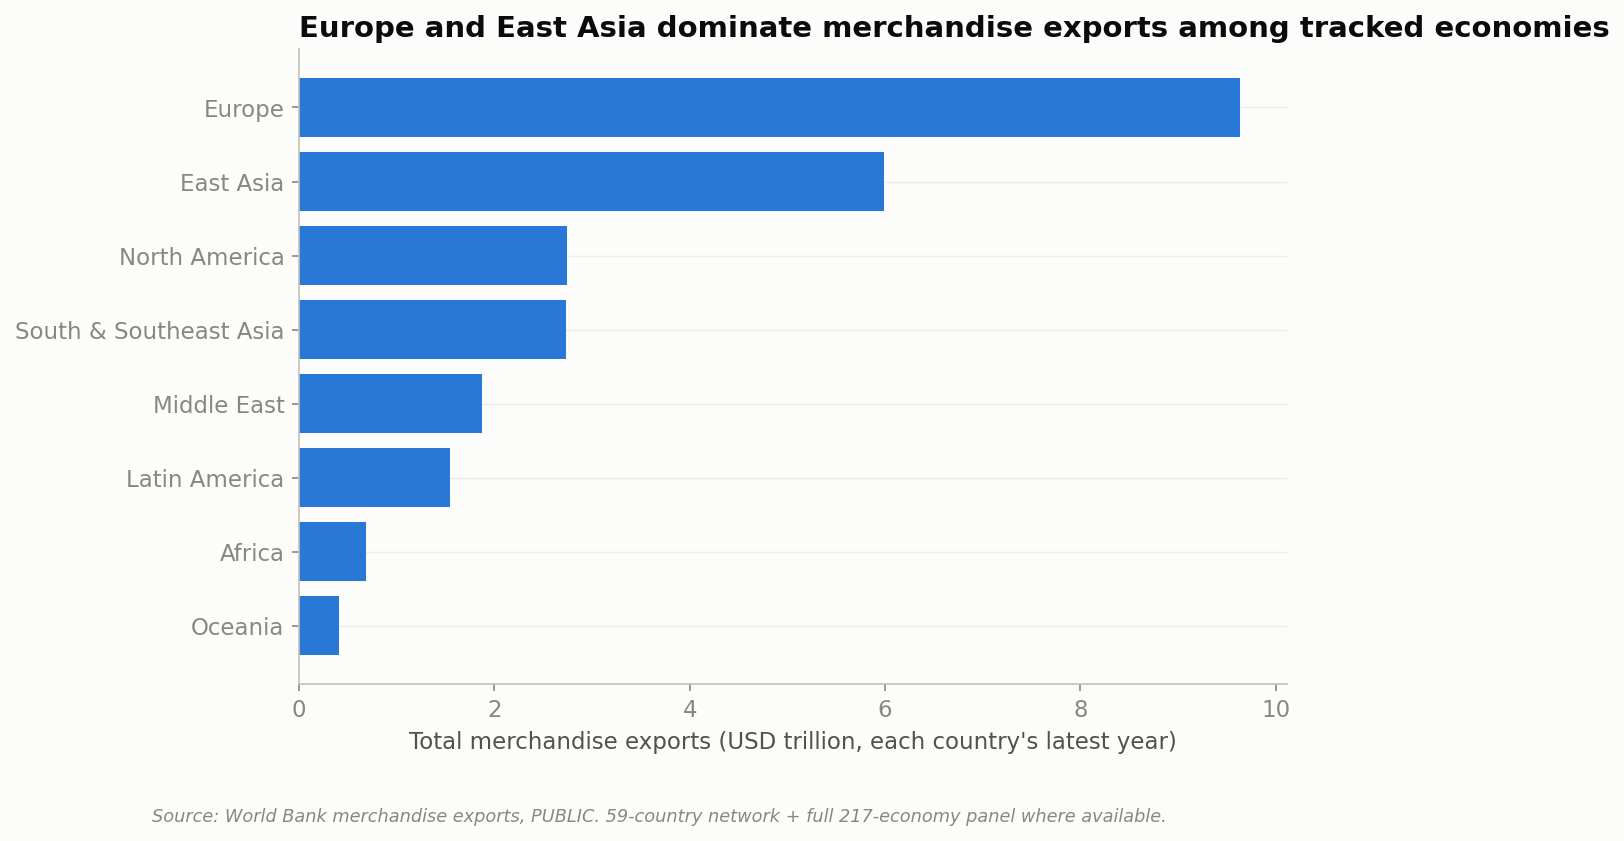

In [3]:
display(Image('../outputs/figures/03_regional_trade_comparison.png', width=700))

## Finding

Europe and East Asia dominate merchandise export volume among tracked economies. This is a raw-volume ranking, deliberately paired with the network-centrality analysis in Notebook 06, which asks a different question (structural importance, not just size).

## Limitation

This uses the full ~217-country World Bank panel for regional totals, not just the 59-country Comtrade network -- the two datasets have different country coverage, stated explicitly rather than silently mixed.

## Next Step

Notebook 04 goes to the country level: who depends on whom.